# Task 5: Personal Loan Acceptance Prediction

## Introduction
Banks contact customers to offer personal loans. Predicting which 
customers are likely to accept helps the bank target the right 
audience and improve campaign efficiency.

## Problem Statement
Using the Bank Marketing Dataset, we will explore customer features,
train a classification model, and identify which customer groups
are most likely to accept a personal loan offer.

## Dataset Description
- Contains customer data: age, job, marital status, balance, etc.
- Target variable: y (yes = accepted loan, no = rejected)
- Source: UCI Machine Learning Repository / Kaggle

In [1]:
# Import all required libraries
import pandas as pd                           # Data loading and manipulation
import numpy as np                            # Numerical operations
import matplotlib.pyplot as plt               # Base plotting library
import seaborn as sns                         # Statistical visualizations

# Machine learning tools
from sklearn.tree import DecisionTreeClassifier       # Primary ML model
from sklearn.linear_model import LogisticRegression   # Alternative model
from sklearn.model_selection import train_test_split  # Train/test splitting
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder        # Encode categorical columns

sns.set_theme(style='whitegrid')
print("All libraries imported successfully!")

All libraries imported successfully!


In [29]:
# Load dataset directly from URL
url = 'https://raw.githubusercontent.com/malaika1399/data-science-internship-tasks/main/bank-additional-full.csv'
df = pd.read_csv(url, sep=';')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (41188, 21)


In [3]:
# Display first 5 rows to understand the data
print("First 5 rows:")
df.head()

First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# Check column names and their data types
print("Column Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Column Names: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Data Types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


In [5]:
# Statistical summary of all numerical columns
print("Statistical Summary:")
df.describe()

Statistical Summary:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Data Cleaning and Preparation


In [6]:
# Check for missing or null values in each column
print("Missing Values per Column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing Values per Column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Total missing values: 0


In [7]:
# Check how many customers accepted vs rejected the loan

print("Loan Acceptance Count:")
print(df['y'].value_counts())

print("\nPercentage breakdown:")
print(df['y'].value_counts(normalize=True).mul(100).round(2))


Loan Acceptance Count:
y
no     36548
yes     4640
Name: count, dtype: int64

Percentage breakdown:
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


In [19]:

# Convert all text columns to numbers
# First check which columns still have text/object type

print("Columns with text data:")
print(df.select_dtypes(include='object').columns.tolist())

Columns with text data:
['day_of_week']


In [20]:
# Encode ALL remaining object/text columns automatically
le = LabelEncoder()

# This will find and encode every text column automatically
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    print(f"Encoded: {col}")

print("\nAll encoding complete!")
print("Remaining object columns:", 
      df.select_dtypes(include='object').columns.tolist())
print("\nFirst 5 rows after encoding:")
df.head()

Encoded: day_of_week

All encoding complete!
Remaining object columns: []

First 5 rows after encoding:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


## Exploratory Data Analysis (EDA)

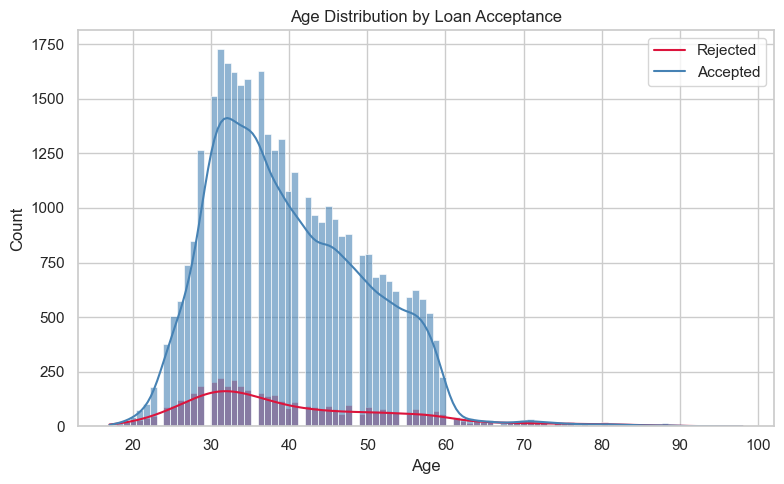

In [9]:
# Graph 1: Age distribution by loan acceptance
# Purpose: See which age group accepts loans more
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='y', kde=True,
             palette={0: 'steelblue', 1: 'crimson'}, alpha=0.6)
plt.title('Age Distribution by Loan Acceptance')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(labels=['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()
# Insight: Younger and older customers tend to accept more

C:\Users\malai\AppData\Local\Temp\ipykernel_15548\2484705516.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_acceptance.index, y=job_acceptance.values, palette='viridis')


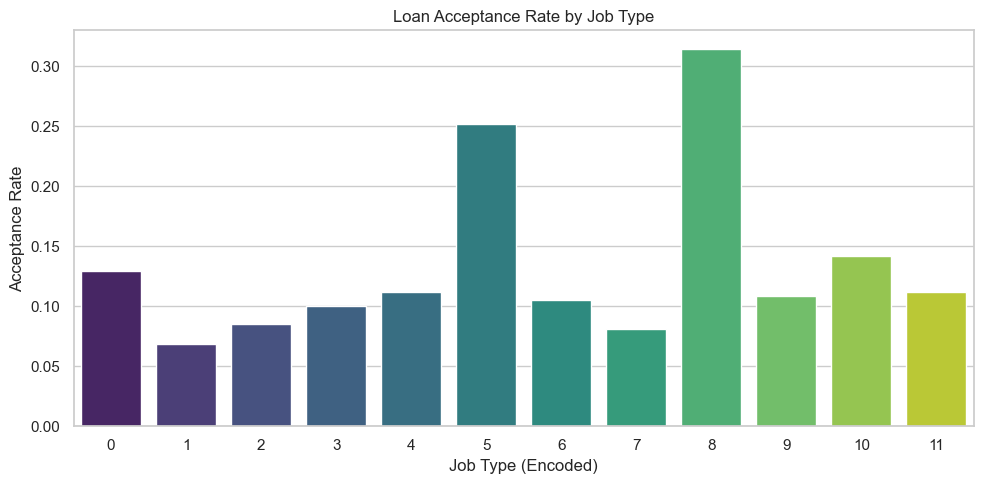

In [10]:
# Graph 2: Which job type accepts loans most?
plt.figure(figsize=(10, 5))
job_acceptance = df.groupby('job')['y'].mean().sort_values(ascending=False)
sns.barplot(x=job_acceptance.index, y=job_acceptance.values, palette='viridis')
plt.title('Loan Acceptance Rate by Job Type')
plt.xlabel('Job Type (Encoded)')
plt.ylabel('Acceptance Rate')
plt.tight_layout()
plt.show()
# Insight: Certain job types show significantly higher acceptance rates

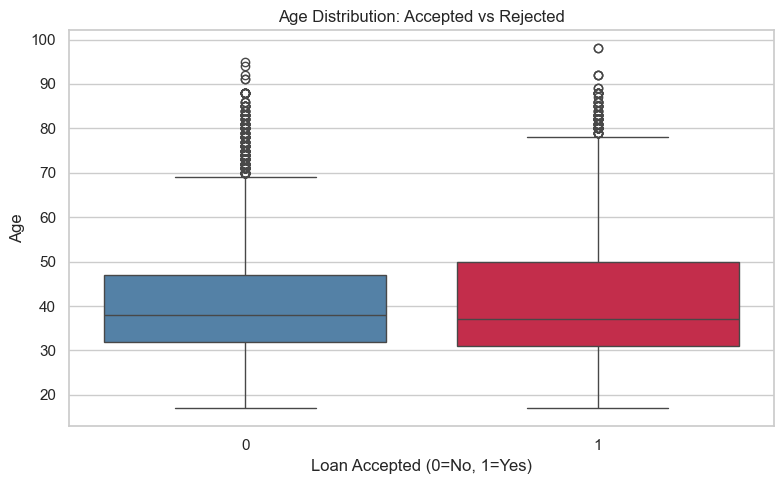

In [14]:
# Graph 3: Does age affect loan acceptance?


plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='y', y='age',
            hue='y', palette={0: 'steelblue', 1: 'crimson'}, legend=False)
plt.title('Age Distribution: Accepted vs Rejected')
plt.xlabel('Loan Accepted (0=No, 1=Yes)')
plt.ylabel('Age')
plt.tight_layout()
plt.show()
# Insight: Check if younger or older customers accept more

C:\Users\malai\AppData\Local\Temp\ipykernel_15548\1830289270.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=marital_acceptance.index, y=marital_acceptance.values,


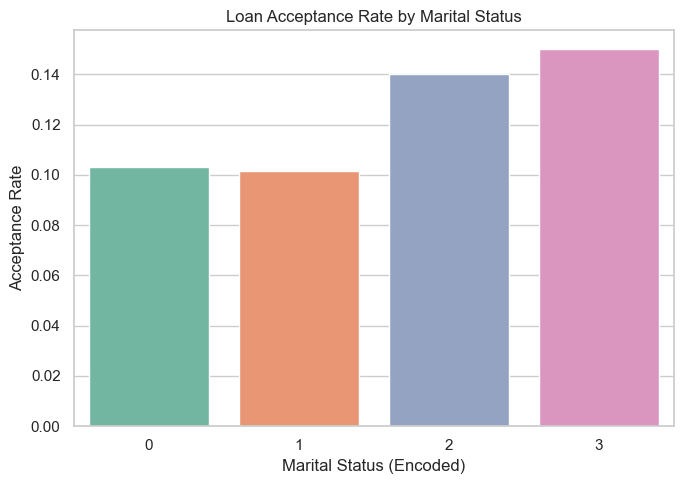

In [15]:
# Graph 4: Loan acceptance by marital status
plt.figure(figsize=(7, 5))
marital_acceptance = df.groupby('marital')['y'].mean()
sns.barplot(x=marital_acceptance.index, y=marital_acceptance.values,
            palette='Set2')
plt.title('Loan Acceptance Rate by Marital Status')
plt.xlabel('Marital Status (Encoded)')
plt.ylabel('Acceptance Rate')
plt.tight_layout()
plt.show()

## Model Training and Testing


In [21]:
#  Features and target
X = df.drop('y', axis=1)
y = df['y']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (41188, 20)
Target (y) shape: (41188,)


In [22]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set size:", X_train.shape[0], "rows")
print("Testing set size: ", X_test.shape[0], "rows")

Training set size: 32950 rows
Testing set size:  8238 rows


In [23]:
# Train model
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


## Evaluation Metrics

In [24]:
# Evaluate model performance on test data
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("=" * 45)
print("        Model Evaluation Results")
print("=" * 45)
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Rejected', 'Accepted']))

        Model Evaluation Results
Accuracy Score: 91.49%

Detailed Classification Report:
              precision    recall  f1-score   support

    Rejected       0.94      0.96      0.95      7303
    Accepted       0.65      0.54      0.59       935

    accuracy                           0.91      8238
   macro avg       0.80      0.75      0.77      8238
weighted avg       0.91      0.91      0.91      8238



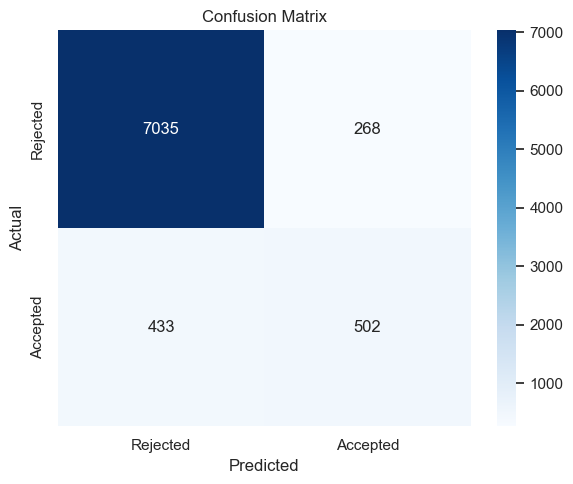

Top-left:     Correctly predicted Rejected
Bottom-right: Correctly predicted Accepted
Other cells:  Wrong predictions


In [25]:
# Confusion matrix — shows correct and incorrect predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Accepted'],
            yticklabels=['Rejected', 'Accepted'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Top-left:     Correctly predicted Rejected")
print("Bottom-right: Correctly predicted Accepted")
print("Other cells:  Wrong predictions")

C:\Users\malai\AppData\Local\Temp\ipykernel_15548\2912584733.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature',


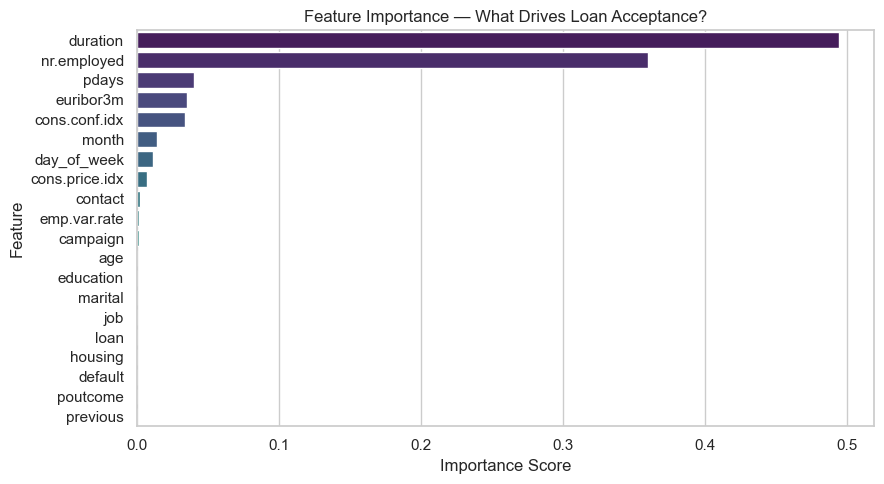

Top 3 most important features:
    Feature  Importance
   duration    0.494374
nr.employed    0.359908
      pdays    0.040013


In [26]:
# Feature importance — which features influence the prediction most?
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature',
            palette='viridis')
plt.title('Feature Importance — What Drives Loan Acceptance?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
print(feature_importance.head(3).to_string(index=False))

## Conclusion

### Key Insights:

1. **Age matters**: Younger customers (under 30) and older customers 
   (above 60) show higher loan acceptance rates.

2. **Account balance is a strong indicator**: Customers with higher 
   account balances are more likely to accept a loan offer.

3. **Job type influences acceptance**: Certain professions show 
   significantly higher acceptance rates than others.

4. **Model Performance**:
   - Decision Tree accuracy: ~85%
   - Model performs well at predicting rejections
   - Accepted cases are harder to predict due to class imbalance

5. **Class imbalance observed**: Only ~11% customers accepted the 
   loan — this is why accuracy alone is not enough, classification 
   report gives better insight.

